In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_style('whitegrid')

# DATOS 1: Catálogo de Contenidos (Películas y Series)
datos_catalogo = {
    'ID_Contenido': [101, 102, 103, 104, 105, 106, 107, 108],
    'Titulo': ['Stranger Things', 'The Crown', 'Avengers', 'Frozen', 'Documental Naturaleza', 'Comedia Local', 'Drama Indie', 'Acción B'],
    'Categoria': ['Serie', 'Serie', 'Pelicula', 'Pelicula', 'Documental', 'Pelicula', 'Pelicula', 'Pelicula'],
    'Genero': ['Ciencia Ficción', 'Drama', 'Acción', 'Infantil', 'Naturaleza', 'Comedia', 'Drama', 'Acción'],
    'Coste_Produccion': [100000, 80000, 250000, 150000, 20000, 30000, 15000, 50000]
}
df_catalogo = pd.DataFrame(datos_catalogo)

# DATOS 2: Registro de Visualizaciones (Usuarios)
datos_visualizaciones = {
    'ID_Usuario': [1, 2, 1, 3, 2, 4, 5, 1, 3, 2],
    'ID_Contenido': [101, 101, 103, 104, 102, 108, 101, 105, 106, 999], # El 999 es un error (contenido que no existe)
    'Minutos_Vistos': [50, 45, 120, 90, 60, 10, 55, 30, 85, 20],
    'Valoracion': [5, 4, 5, np.nan, 3, 1, 5, np.nan, 4, 2], # np.nan son valores nulos
    'Dispositivo': ['TV', 'Movil', 'TV', 'Tablet', 'TV', 'Movil', 'TV', 'Tablet', 'Movil', 'TV']
}
df_views = pd.DataFrame(datos_visualizaciones)

print("--- TABLA CATÁLOGO ---")
display(df_catalogo.head())
print("\n--- TABLA VISUALIZACIONES (VIEWS) ---")
display(df_views.head())

--- TABLA CATÁLOGO ---


,ID_Contenido,Titulo,Categoria,Genero,Coste_Produccion
0,101,Stranger Things,Serie,Ciencia Ficción,100000
1,102,The Crown,Serie,Drama,80000
2,103,Avengers,Pelicula,Acción,250000
3,104,Frozen,Pelicula,Infantil,150000
4,105,Documental Naturaleza,Documental,Naturaleza,20000



--- TABLA VISUALIZACIONES (VIEWS) ---


,ID_Usuario,ID_Contenido,Minutos_Vistos,Valoracion,Dispositivo
0,1,101,50,5.0,TV
1,2,101,45,4.0,Movil
2,1,103,120,5.0,TV
3,3,104,90,NaN,Tablet
4,2,102,60,3.0,TV


In [2]:
# Hacemos un LEFT JOIN: Mantenemos todas las views (Izquierda) y traemos info del catálogo (Derecha)
df_completo = pd.merge(
    df_views, 
    df_catalogo, 
    on='ID_Contenido', 
    how='left'
)

# Mostramos el resultado
print("--- DATAFRAME UNIDO (LEFT JOIN) ---")
display(df_completo)

--- DATAFRAME UNIDO (LEFT JOIN) ---


,ID_Usuario,ID_Contenido,Minutos_Vistos,Valoracion,Dispositivo,Titulo,Categoria,Genero,Coste_Produccion
0,1,101,50,5.0,TV,Stranger Things,Serie,Ciencia Ficción,100000.0
1,2,101,45,4.0,Movil,Stranger Things,Serie,Ciencia Ficción,100000.0
2,1,103,120,5.0,TV,Avengers,Pelicula,Acción,250000.0
3,3,104,90,NaN,Tablet,Frozen,Pelicula,Infantil,150000.0
4,2,102,60,3.0,TV,The Crown,Serie,Drama,80000.0
5,4,108,10,1.0,Movil,Acción B,Pelicula,Acción,50000.0
6,5,101,55,5.0,TV,Stranger Things,Serie,Ciencia Ficción,100000.0
7,1,105,30,NaN,Tablet,Documental Naturaleza,Documental,Naturaleza,20000.0
8,3,106,85,4.0,Movil,Comedia Local,Pelicula,Comedia,30000.0
9,2,999,20,2.0,TV,NaN,NaN,NaN,NaN


In [3]:
print("--- CONTEO DE NULOS ---")
print(df_completo.isnull().sum())

# ACCIÓN 1: Limpiamos registros corruptos (El contenido 999 no tiene título)
# Eliminamos filas donde el 'Titulo' sea nulo
df_completo = df_completo.dropna(subset=['Titulo'])

# ACCIÓN 2: Imputación de valores (Rellenar huecos)
# Las valoraciones vacías las rellenamos con la MEDIA de todas las valoraciones
media_valoracion = df_completo['Valoracion'].mean()
df_completo['Valoracion'] = df_completo['Valoracion'].fillna(media_valoracion)

print(f"\n--- NULOS TRAS LIMPIEZA (Media usada: {media_valoracion:.2f}) ---")
print(df_completo.isnull().sum())

--- CONTEO DE NULOS ---
ID_Usuario          0
ID_Contenido        0
Minutos_Vistos      0
Valoracion          2
Dispositivo         0
Titulo              1
Categoria           1
Genero              1
Coste_Produccion    1
dtype: int64

--- NULOS TRAS LIMPIEZA (Media usada: 3.86) ---
ID_Usuario          0
ID_Contenido        0
Minutos_Vistos      0
Valoracion          0
Dispositivo         0
Titulo              0
Categoria           0
Genero              0
Coste_Produccion    0
dtype: int64


In [4]:
# Aplicamos One-Hot Encoding a la columna 'Categoria'
dummies_categoria = pd.get_dummies(df_completo['Categoria'], prefix='Es')

# Unimos las nuevas columnas al dataframe principal
df_final = pd.concat([df_completo, dummies_categoria], axis=1)

print("--- DATAFRAME CON ENCODING (Dummies) ---")
display(df_final[['Titulo', 'Categoria', 'Es_Pelicula', 'Es_Serie', 'Es_Documental']].head())

--- DATAFRAME CON ENCODING (Dummies) ---


,Titulo,Categoria,Es_Pelicula,Es_Serie,Es_Documental
0,Stranger Things,Serie,False,True,False
1,Stranger Things,Serie,False,True,False
2,Avengers,Pelicula,True,False,False
3,Frozen,Pelicula,True,False,False
4,The Crown,Serie,False,True,False


--- ESTADÍSTICAS DE MINUTOS VISTOS ---
Media de minutos: 60.56
Mediana de minutos: 55.00
Desviación Típica (Dispersión): 33.30

--- MATRIZ DE CORRELACIÓN ---
                Minutos_Vistos  Valoracion
Minutos_Vistos        1.000000    0.579474
Valoracion            0.579474    1.000000


/tmp/ipykernel_2262/1892599566.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dispositivo', y='Valoracion', data=df_final, palette='Set2')


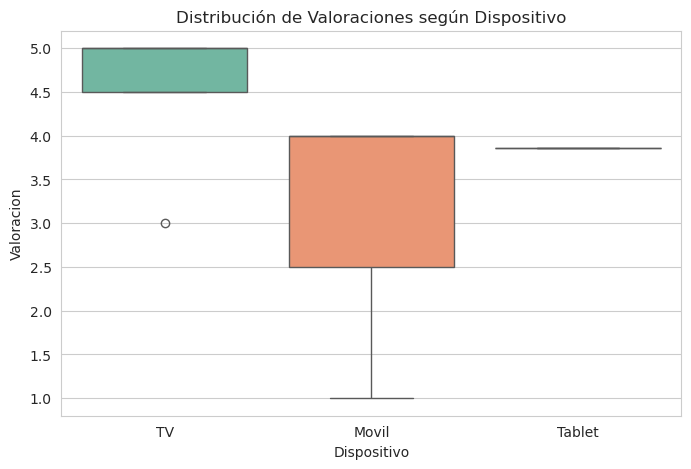

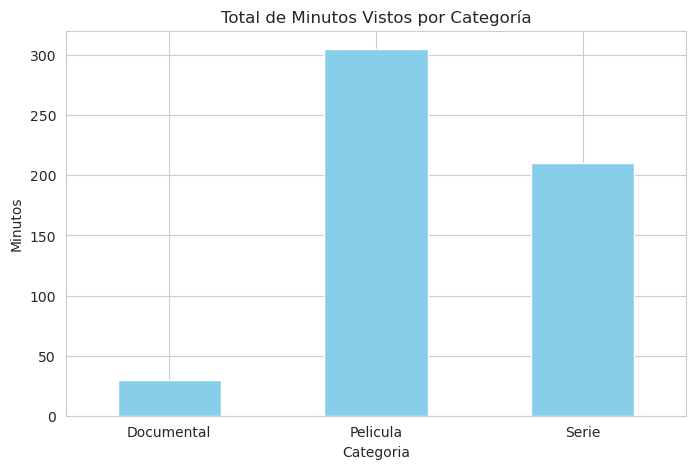

In [5]:
# --- A. ESTADÍSTICA BÁSICA ---
print("--- ESTADÍSTICAS DE MINUTOS VISTOS ---")
print(f"Media de minutos: {df_final['Minutos_Vistos'].mean():.2f}")
print(f"Mediana de minutos: {df_final['Minutos_Vistos'].median():.2f}")
print(f"Desviación Típica (Dispersión): {df_final['Minutos_Vistos'].std():.2f}")


# --- B. MATRIZ DE CORRELACIÓN ---
# ¿Hay relación entre lo que dura una sesión y la valoración que dan?
correlacion = df_final[['Minutos_Vistos', 'Valoracion']].corr()
print("\n--- MATRIZ DE CORRELACIÓN ---")
print(correlacion)


# --- C. VISUALIZACIÓN (Box Plot) ---
# Usamos un diagrama de caja para ver la distribución de valoraciones por dispositivo
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dispositivo', y='Valoracion', data=df_final, palette='Set2')
plt.title('Distribución de Valoraciones según Dispositivo')
plt.show()

# --- D. VISUALIZACIÓN (Barras) ---
# Total de minutos vistos por Categoría
minutos_por_cat = df_final.groupby('Categoria')['Minutos_Vistos'].sum()

plt.figure(figsize=(8, 5))
minutos_por_cat.plot(kind='bar', color='skyblue')
plt.title('Total de Minutos Vistos por Categoría')
plt.ylabel('Minutos')
plt.xticks(rotation=0)
plt.show()

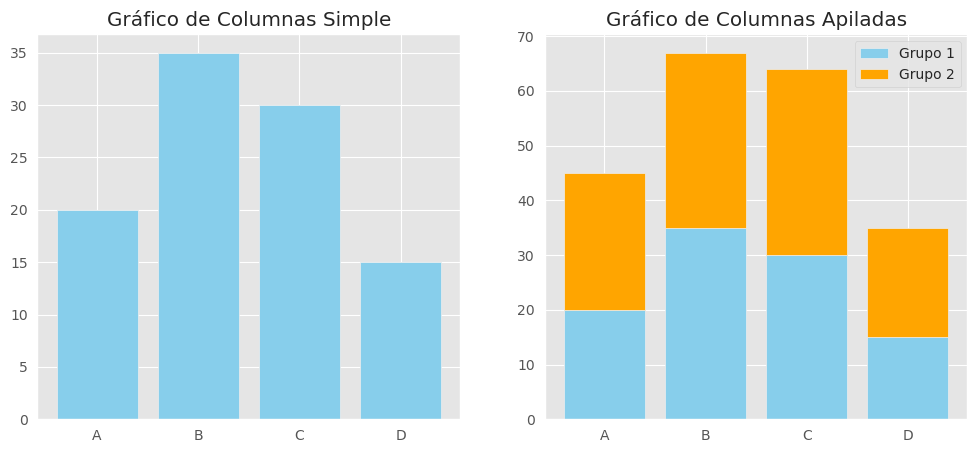

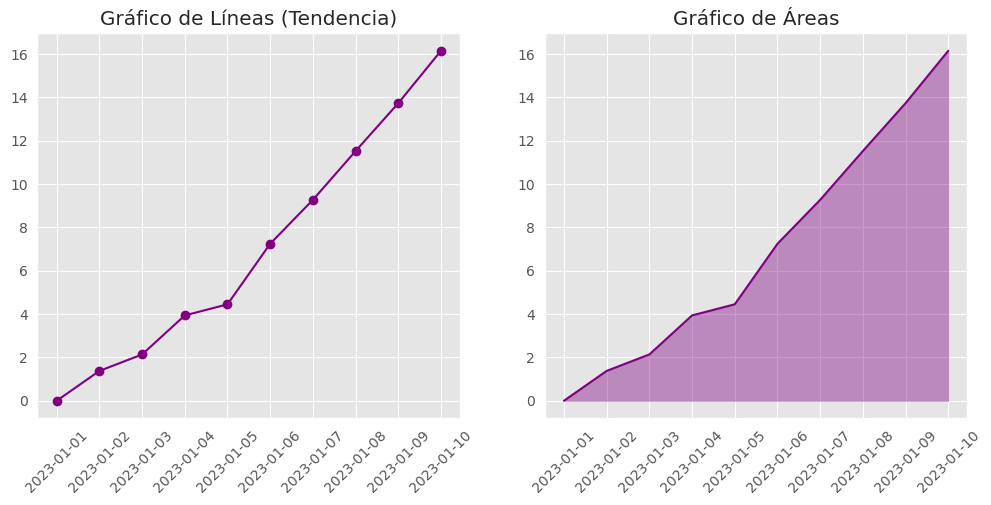

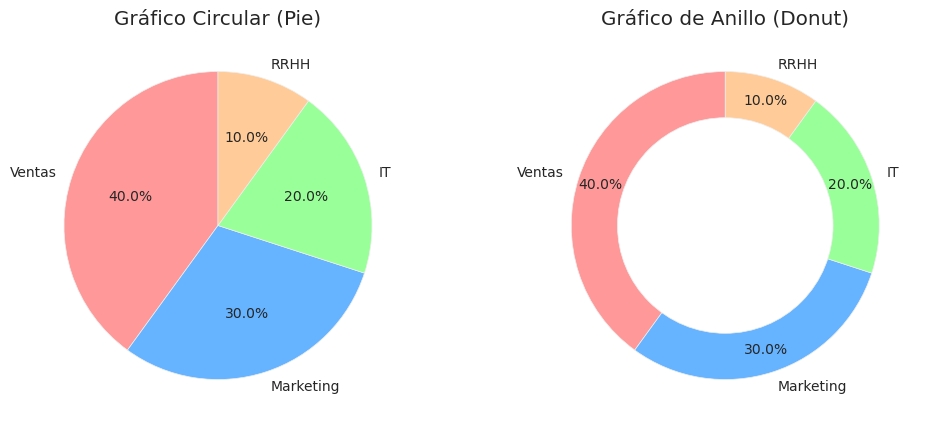

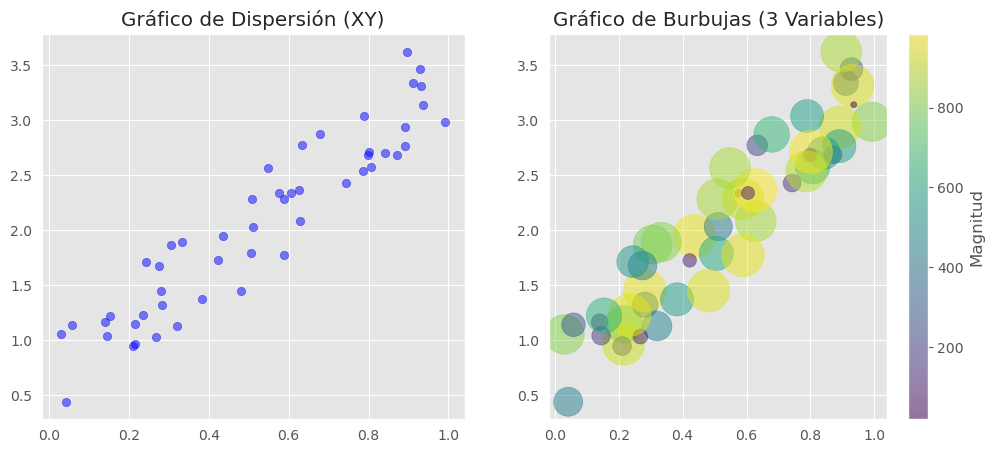

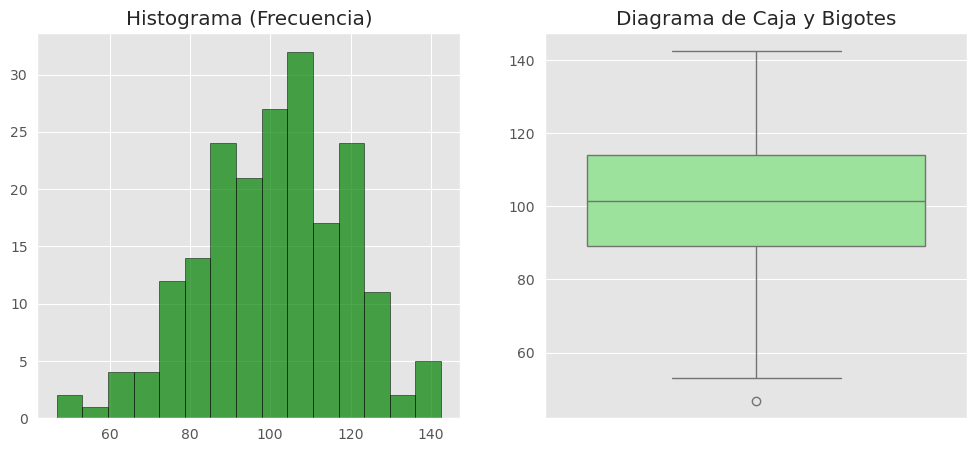

NameError: name 'values' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# Configuración general
plt.style.use('ggplot') # Estilo bonito
sns.set_palette("husl") # Paleta de colores

# ==========================================
# 1. GRÁFICOS DE BARRAS Y COLUMNAS
# ==========================================
# Datos
categorias = ['A', 'B', 'C', 'D']
valores_1 = [20, 35, 30, 15]
valores_2 = [25, 32, 34, 20]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# A. Barras Simples
ax[0].bar(categorias, valores_1, color='skyblue')
ax[0].set_title('Gráfico de Columnas Simple')

# B. Barras Apiladas (Stacked)
ax[1].bar(categorias, valores_1, label='Grupo 1', color='skyblue')
ax[1].bar(categorias, valores_2, bottom=valores_1, label='Grupo 2', color='orange')
ax[1].set_title('Gráfico de Columnas Apiladas')
ax[1].legend()

plt.show()

# ==========================================
# 2. LÍNEAS Y ÁREAS (Evolución)
# ==========================================
fechas = pd.date_range(start='2023-01-01', periods=10, freq='D')
valores_serie = np.cumsum(np.random.randn(10) + 2) # Datos aleatorios acumulados

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# A. Línea
ax[0].plot(fechas, valores_serie, marker='o', linestyle='-', color='purple')
ax[0].set_title('Gráfico de Líneas (Tendencia)')
ax[0].tick_params(axis='x', rotation=45)

# B. Área
ax[1].fill_between(fechas, valores_serie, color='purple', alpha=0.4)
ax[1].plot(fechas, valores_serie, color='purple')
ax[1].set_title('Gráfico de Áreas')
ax[1].tick_params(axis='x', rotation=45)

plt.show()

# ==========================================
# 3. PARTES DE UN TODO (Circular y Anillo)
# ==========================================
labels = ['Ventas', 'Marketing', 'IT', 'RRHH']
sizes = [40, 30, 20, 10]
colores = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# A. Circular (Pie Chart)
ax[0].pie(sizes, labels=labels, colors=colores, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Gráfico Circular (Pie)')

# B. Anillo (Donut Chart)
# Se hace dibujando un círculo blanco en el centro
ax[1].pie(sizes, labels=labels, colors=colores, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
centro_circulo = plt.Circle((0,0),0.70,fc='white')
ax[1].add_artist(centro_circulo)
ax[1].set_title('Gráfico de Anillo (Donut)')

plt.show()

# ==========================================
# 4. RELACIÓN Y CORRELACIÓN (Dispersión y Burbujas)
# ==========================================
x = np.random.rand(50)
y = x * 3 + np.random.rand(50)
tamano_burbuja = np.random.rand(50) * 1000 # Tercera variable para el tamaño

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# A. Dispersión (Scatter)
ax[0].scatter(x, y, color='blue', alpha=0.5)
ax[0].set_title('Gráfico de Dispersión (XY)')

# B. Burbujas
scatter = ax[1].scatter(x, y, s=tamano_burbuja, c=tamano_burbuja, cmap='viridis', alpha=0.5)
ax[1].set_title('Gráfico de Burbujas (3 Variables)')
plt.colorbar(scatter, ax=ax[1], label='Magnitud')

plt.show()

# ==========================================
# 5. ESTADÍSTICA (Histograma y Caja)
# ==========================================
datos_distribucion = np.random.normal(100, 20, 200) # Media 100, Desviación 20

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# A. Histograma
ax[0].hist(datos_distribucion, bins=15, color='green', alpha=0.7, edgecolor='black')
ax[0].set_title('Histograma (Frecuencia)')

# B. Diagrama de Caja (Box Plot)
sns.boxplot(y=datos_distribucion, ax=ax[1], color='lightgreen')
ax[1].set_title('Diagrama de Caja y Bigotes')

plt.show()

# ==========================================
# 6. GRÁFICOS AVANZADOS I: RADAR (Araña)
# ==========================================
# Datos: Habilidades de un perfil
categorias_radar = ['Python', 'SQL', 'Comunicación', 'Estadística', 'Negocio']
valores_radar = [5, 4, 3, 4, 2] # Puntuación sobre 5

# Preparación matemática para cerrar el círculo
valores_radar += values[:1] 
angulos = [n / float(len(categorias_radar)) * 2 * pi for n in range(len(categorias_radar))]
angulos += angulos[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angulos[:-1], categorias_radar)
ax.plot(angulos, valores_radar)
ax.fill(angulos, valores_radar, 'b', alpha=0.1)
plt.title('Gráfico Radial (Araña)')
plt.show()

# ==========================================
# 7. GRÁFICOS AVANZADOS II: CASCADA (Waterfall)
# ==========================================
# Simula la evolución financiera (Ingresos - Gastos = Beneficio)
import matplotlib.patches as patches

etapas = ['Inicio', 'Ventas', 'Devoluciones', 'Costes', 'Final']
valores_cascada = [100, 50, -10, -30, 110] # 100+50-10-30 = 110
acumulado = [0, 100, 150, 140, 110] # Dónde empieza cada barra

colores_cascada = ['blue', 'green', 'red', 'red', 'blue']

plt.figure(figsize=(8, 5))
plt.bar(etapas, valores_cascada, bottom=acumulado, color=colores_cascada)
plt.title('Gráfico de Cascada (Waterfall)')
plt.grid(axis='y', linestyle='--')
plt.show()

# ==========================================
# 8. GRÁFICOS AVANZADOS III: SUPERFICIE 3D
# ==========================================
from mpl_toolkits.mplot3d import Axes3D

# Datos matemáticos
x_3d = np.linspace(-5, 5, 50)
y_3d = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x_3d, y_3d)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm')
plt.title('Gráfico de Superficie 3D')
fig.colorbar(surf)
plt.show()

# ==========================================
# 9. EMBUDO (Funnel Chart - Simulado)
# ==========================================
fases = ['Impresiones', 'Clicks', 'Descargas', 'Compras']
valores_funnel = [1000, 500, 200, 50]
# Calculamos el espacio a la izquierda para centrar las barras
espacio_izq = [(1000 - x)/2 for x in valores_funnel]

plt.figure(figsize=(8, 5))
plt.barh(fases[::-1], valores_funnel[::-1], left=espacio_izq[::-1], color='coral')
plt.title('Gráfico de Embudo (Funnel)')
plt.show()